# 2. Beamforming with numpy

The same beamformer as in notebook 1, with array operations instead of loops: `numpy` then does the loops in fast compiled code. We write it twice:

- with **`einsum`**, which reads like the formula: `np.einsum("j, jk, k ->", a, K, b)` is $\sum_j \sum_k a_j K_{jk} b_k$,
- as a **matrix product**, which is much faster.

Both use **broadcasting**: `a[:, None] * b[None, :]` multiplies every element of `a` with every element of `b`.

## 1. Geometry

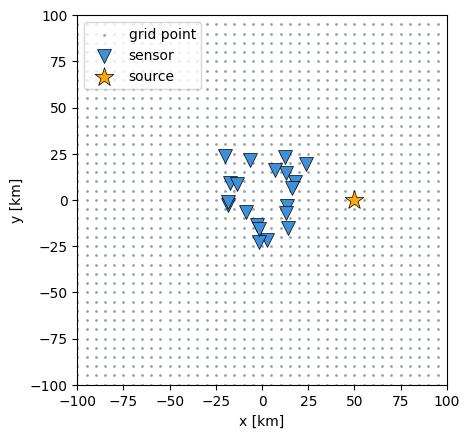

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

# 20 sensors, placed at random in a 50 km x 50 km square
rng = np.random.default_rng(42)
n_sensors = 20
stations = rng.uniform(-25, 25, size=(n_sensors, 2))
source = np.array([50, 0])

# candidate source positions: a grid with 5 km spacing
grid_coords = np.arange(-100, 100, 5)
xx, yy = np.meshgrid(grid_coords, grid_coords, indexing="ij")
gridpoints = np.stack([xx.ravel(), yy.ravel()], axis=1)

fig, ax = plt.subplots()
ax.scatter(*gridpoints.T, s=1, c="#94a4a2", label="grid point")
ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]")
ax.legend(loc="upper left")

## 2. Recordings

The source emits a short pulse. It reaches sensor $j$ after the traveltime $t_j = |\mathbf{r}_j - \mathbf{r}_\text{source}| / c$. In the frequency domain, a delay by $t_j$ is a multiplication with $e^{-i\omega t_j}$. With field data, use the spectra of your recordings instead.

[(0.0, 60.0),
 Text(0.5, 0, 'time [s]'),
 Text(0, 0.5, 'amplitude'),
 Text(0.5, 1.0, 'recordings')]

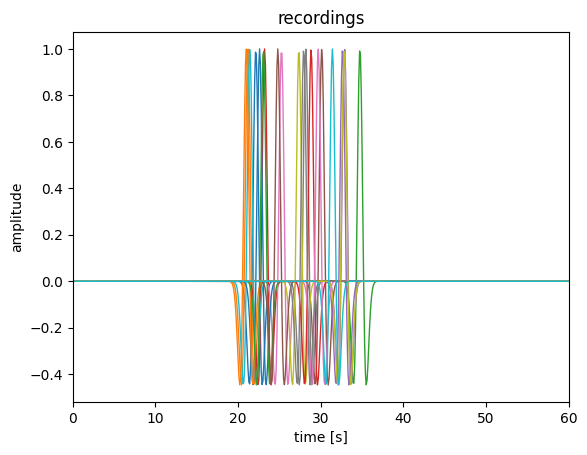

In [2]:
sampling_rate = 10  # Hz
times = np.arange(0, 100, 1 / sampling_rate)  # 100 s
freqs = np.fft.fftfreq(len(times), 1 / sampling_rate)
omega = 2 * np.pi * freqs

medium_velocity = 3  # km/s
traveltimes = np.linalg.norm(stations - source, axis=1) / medium_velocity


def ricker(t, peak_frequency, delay):
    arg = (np.pi * peak_frequency * (t - delay)) ** 2
    return (1 - 2 * arg) * np.exp(-arg)


# every sensor records the same pulse, delayed by its traveltime
pulse_spectrum = np.fft.fft(ricker(times, peak_frequency=0.5, delay=10))
waveform_spectra = pulse_spectrum * np.exp(-1j * omega * traveltimes[:, None])
waveforms = np.fft.ifft(waveform_spectra).real

# we beamform between 0.1 and 1 Hz
band = (freqs > 0.1) & (freqs < 1.0)
omega_band = omega[band]
spectra = waveform_spectra[:, band]

fig, ax = plt.subplots()
ax.plot(times, waveforms.T, lw=1)
ax.set(xlim=(0, 60), xlabel="time [s]", ylabel="amplitude", title="recordings")

## 3. Beamforming with einsum

$B(\mathbf{x}) = \sum_\omega \mathbf{s}^H K\, \mathbf{s}$ (notebook 1), with the steering vectors of all grid points at once:

| | shape | letters in `einsum` |
|---|---|---|
| steering vectors $s$ | (grid points, sensors, frequencies) | `xjw` |
| cross-spectral density matrix $K$ | (sensors, sensors, frequencies) | `jkw` |

In [3]:
def beamform_einsum(stations, gridpoints, omega_band, spectra, medium_velocity):
    # steering vectors of all grid points
    traveltimes = np.linalg.norm(gridpoints[:, None, :] - stations[None, :, :], axis=2) / medium_velocity
    s = np.exp(-1j * omega_band[None, None, :] * traveltimes[:, :, None])
    # cross-spectral density matrix, without the auto-correlations
    K = spectra[:, None, :] * spectra.conj()[None, :, :]
    K[np.arange(len(stations)), np.arange(len(stations)), :] = 0
    # s^H K s for every grid point, summed over frequencies
    return np.einsum("xjw, jkw, xkw -> x", s.conj(), K, s, optimize=True).real


title = "numpy, einsum"
start = time.perf_counter()
beampowers = beamform_einsum(stations, gridpoints, omega_band, spectra, medium_velocity)
print(f"beamforming took {time.perf_counter() - start:.3f} s")

beamforming took 0.326 s


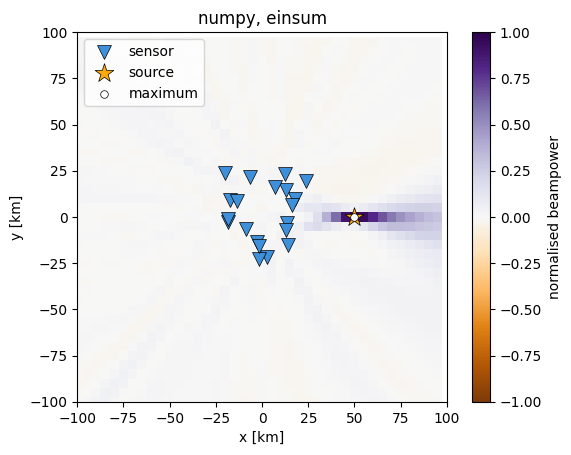

In [4]:
def plot_beampowers(beampowers, title):
    bp = beampowers.reshape(len(grid_coords), len(grid_coords)).T
    bp = bp / np.abs(bp).max()
    fig, ax = plt.subplots()
    pcm = ax.pcolormesh(grid_coords, grid_coords, bp, cmap="PuOr", vmin=-1, vmax=1, shading="nearest")
    ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
    ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
    ax.scatter(*gridpoints[np.argmax(beampowers)], marker="o", s=30, c="w", ec="k", lw=0.5, label="maximum")
    fig.colorbar(pcm, label="normalised beampower")
    ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]", title=title)
    ax.legend(loc="upper left")


plot_beampowers(beampowers, title)

The same map as in notebook 1.

## 4. Beamforming as a matrix product

For one frequency, the steering vectors of all grid points form a matrix $S$ (grid points × sensors). Then `S.conj() @ K` computes $\mathbf{s}^H K$ for all grid points in one matrix product. `numpy` hands matrix products to a linear-algebra library (BLAS) that is tuned for the processor and uses all its cores; `einsum` with three arrays runs on one core. We loop over the frequencies, which also keeps the arrays small:

In [5]:
def beamform_matmul(stations, gridpoints, omega_band, spectra, medium_velocity):
    traveltimes = np.linalg.norm(gridpoints[:, None, :] - stations[None, :, :], axis=2) / medium_velocity
    beampowers = np.zeros(len(gridpoints))
    for w in range(len(omega_band)):
        # cross-spectral density matrix at this frequency, without the auto-correlations
        K = np.outer(spectra[:, w], spectra[:, w].conj())
        np.fill_diagonal(K, 0)
        s = np.exp(-1j * omega_band[w] * traveltimes)  # steering vectors, (grid points, sensors)
        beampowers += np.sum((s.conj() @ K) * s, axis=1).real  # s^H K s
    return beampowers


start = time.perf_counter()
beampowers_matmul = beamform_matmul(stations, gridpoints, omega_band, spectra, medium_velocity)
print(f"beamforming took {time.perf_counter() - start:.3f} s")
print("same result as einsum:", np.allclose(beampowers_matmul, beampowers))

beamforming took 0.132 s
same result as einsum: True


## 5. einsum vs. matrix product

With more sensors:

In [6]:
for n in [20, 50, 100]:
    more_stations = rng.uniform(-25, 25, size=(n, 2))
    more_spectra = pulse_spectrum[band] * np.exp(
        -1j * omega_band * np.linalg.norm(more_stations - source, axis=1)[:, None] / medium_velocity
    )
    runtimes = []
    for beamform in (beamform_einsum, beamform_matmul):
        start = time.perf_counter()
        beamform(more_stations, gridpoints, omega_band, more_spectra, medium_velocity)
        runtimes.append(time.perf_counter() - start)
    print(f"{n:4d} sensors:  einsum {runtimes[0]:6.2f} s,  matrix product {runtimes[1]:6.2f} s")

  20 sensors:  einsum   0.33 s,  matrix product   0.13 s


  50 sensors:  einsum   1.75 s,  matrix product   0.49 s


 100 sensors:  einsum   6.93 s,  matrix product   0.89 s


The matrix product is the version to build on. Both grow with $n_\text{sensors}^2$: $K$ has one entry per pair of sensors.

Everything a beamformer needs from the recordings is in $K$. That makes this form general:

- $K$ can be averaged over many time windows, or its pairs can be weighted or normalised before beamforming.
- Other beamformers (MVDR, MUSIC) replace $K$ by a matrix computed from it; the rest stays the same (notebook 4).

Notebook 3 writes the same in other libraries, and compares their speed. If the grid or the recordings do not fit into memory, process them in pieces (see the README).